In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import rank
from skimage.morphology import disk
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import scipy.io as io
from tqdm import tqdm
import joblib

# ------------------------
# 1. Download and Load Dataset
# ------------------------
# Download the .mat file from Zenodo
!wget "https://zenodo.org/records/1009146/files/dataset_liver_bmodes_steatosis_assessment_IJCARS.mat?download=1" -O dataset.mat

# Load the .mat file
mat = io.loadmat('dataset.mat', squeeze_me=True, struct_as_record=False)
data = mat['data']

# Number of patients
num_patients = len(data)
patient_ids = [f'patient_{i+1}' for i in range(num_patients)]

--2025-10-17 03:09:10--  https://zenodo.org/records/1009146/files/dataset_liver_bmodes_steatosis_assessment_IJCARS.mat?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 52388549 (50M) [application/octet-stream]
Saving to: ‘dataset.mat’

dataset.mat         100%[===================>]  49.96M   860KB/s    in 71s     

2025-10-17 03:10:22 (716 KB/s) - ‘dataset.mat’ saved [52388549/52388549]



In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the .mat file
mat = scipy.io.loadmat("dataset.mat")

# 2. Inspect keys (attributes / variables in the file)
data = mat['data']

print(type(data))
print(data.shape)
print(data.dtype)
print(data.dtype.names)  # shows field names inside 'data'




<class 'numpy.ndarray'>
(1, 55)
[('id', 'O'), ('class', 'O'), ('fat', 'O'), ('images', 'O')]
('id', 'class', 'fat', 'images')


Row 1: ID=[1], Class=[0], Fat=[3], Image shape=(10, 434, 636)


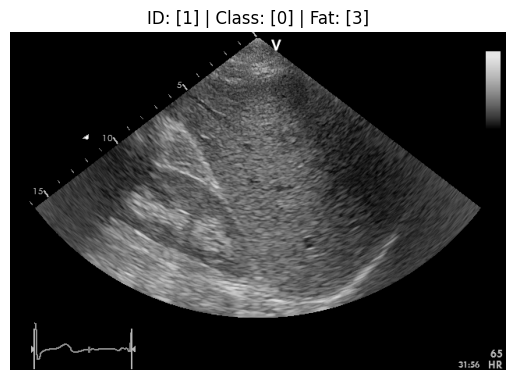

Row 2: ID=[2], Class=[0], Fat=[4], Image shape=(10, 434, 636)


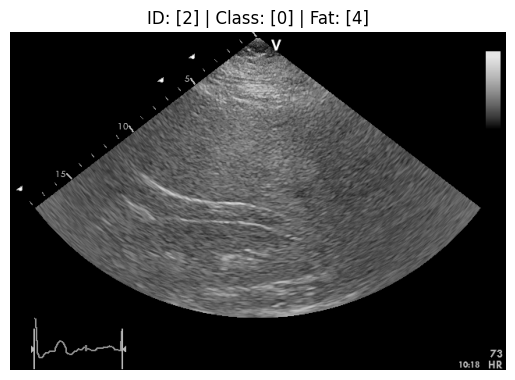

Row 3: ID=[3], Class=[0], Fat=[2], Image shape=(10, 434, 636)


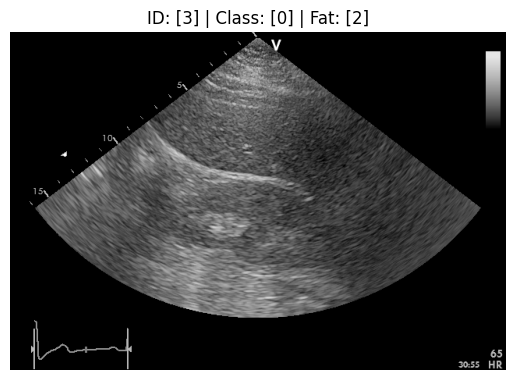

Row 4: ID=[4], Class=[0], Fat=[1], Image shape=(10, 434, 636)


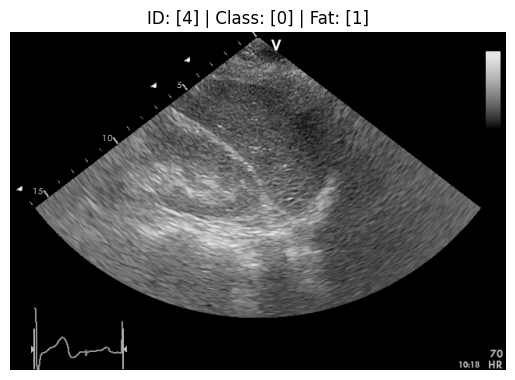

Row 5: ID=[5], Class=[0], Fat=[2], Image shape=(10, 434, 636)


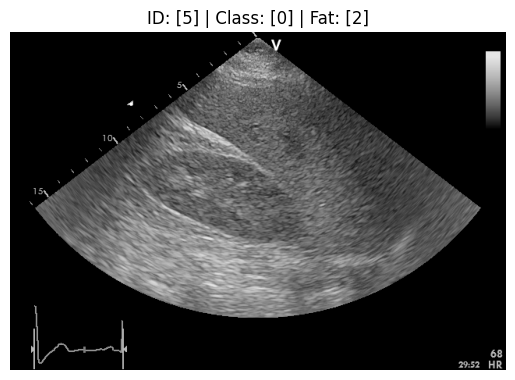

In [ ]:
import scipy.io
import matplotlib.pyplot as plt

# Load .mat
mat = scipy.io.loadmat("dataset.mat")
data = mat['data']
records = data[0]
for i in range(5):
    rec = records[i]

    sample_id = rec['id'][0]
    sample_class = rec['class'][0]
    sample_fat = rec['fat'][0]
    img_stack= rec['images']   # likely a 2D grayscale image

    print(f"Row {i+1}: ID={sample_id}, Class={sample_class}, Fat={sample_fat}, Image shape={img_stack.shape}")
    frame = img_stack[img_stack.shape[0] // 2, :, :]
    plt.imshow(frame, cmap='gray')
    plt.title(f"ID: {sample_id} | Class: {sample_class} | Fat: {sample_fat}")
    plt.axis('off')
    plt.show()




Splitting patients to create an image-wise dataset...
Total training images: 440
Total testing images: 110

Using device: cuda

Extracting features from training images...


100%|██████████| 440/440 [01:51<00:00,  3.94it/s]



Extracting features from testing images...


100%|██████████| 110/110 [00:27<00:00,  4.03it/s]


Training XGBoost Regressor with GridSearchCV...
Fitting 3 folds for each of 8 candidates, totalling 24 fits



Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

--- Model Evaluation on Test Set ---

--- Regression Performance ---
Mean Absolute Error (MAE): 17.05%
R-squared (R2 Score): 0.295

--- Derived Classification Performance ---
Derived Accuracy: 0.809
              precision    recall  f1-score   support

   Non-fatty       0.87      0.90      0.89        90
       Fatty       0.47      0.40      0.43        20

    accuracy                           0.81       110
   macro avg       0.67      0.65      0.66       110
weighted avg       0.80      0.81      0.80       110



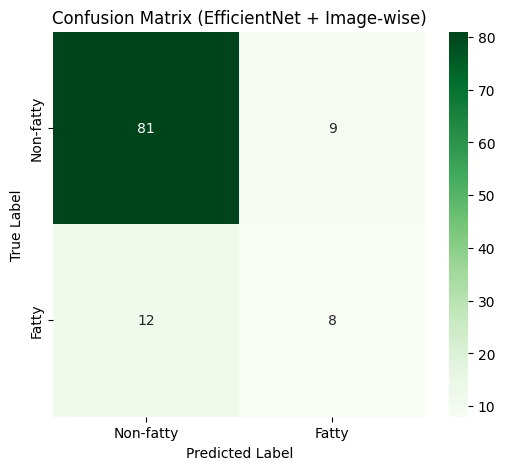

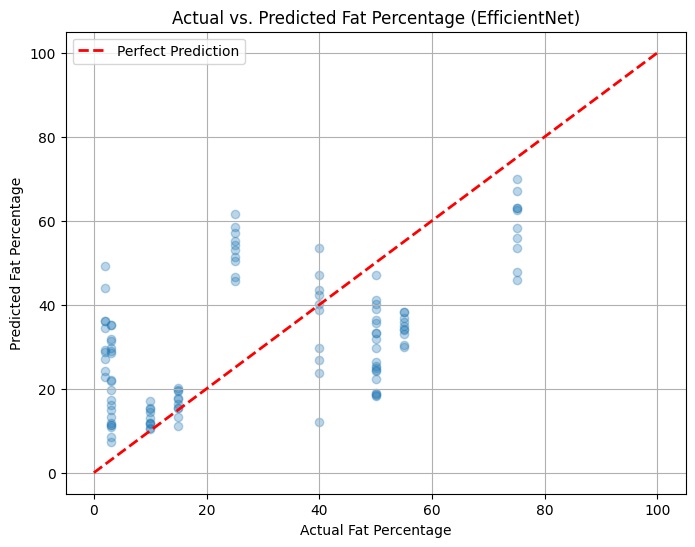


Final model saved as xgb_efficientnet_image_wise_regressor.pkl


In [ ]:
# =================================================================
# Final Model: Image-Wise Prediction with EfficientNet Features
# =================================================================

import os
import cv2
import numpy as np
from tqdm import tqdm
import scipy.io as sio
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from skimage.filters import rank
from skimage.morphology import disk
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (mean_absolute_error, r2_score,
                             confusion_matrix, classification_report, accuracy_score)
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

# ------------------------
# 1. Load Dataset
# ------------------------
if not os.path.exists('dataset.mat'):
    print("Downloading dataset...")
    os.system('wget "https://zenodo.org/records/1009146/files/dataset_liver_bmodes_steatosis_assessment_IJCARS.mat?download=1" -O dataset.mat')
    print("Download complete.")

mat = sio.loadmat('dataset.mat', squeeze_me=True, struct_as_record=False)
data = mat['data']
num_patients = len(data)

# ------------------------
# 2. Create Image-wise Dataset (Patient-Safe Split)
# ------------------------
print("\nSplitting patients to create an image-wise dataset...")

# First, split by PATIENT to prevent data leakage
patient_indices = np.arange(num_patients)
train_patient_idx, test_patient_idx = train_test_split(patient_indices, test_size=0.2, random_state=42)

# Unpack images and labels from the split patients
train_images, train_labels = [], []
for idx in train_patient_idx:
    patient_fat_label = data[idx].fat
    for image in data[idx].images:
        train_images.append(image)
        train_labels.append(patient_fat_label)

test_images, test_labels = [], []
for idx in test_patient_idx:
    patient_fat_label = data[idx].fat
    for image in data[idx].images:
        test_images.append(image)
        test_labels.append(patient_fat_label)

print(f"Total training images: {len(train_images)}")
print(f"Total testing images: {len(test_images)}")

y_train_actual = np.array(train_labels)
y_test_actual = np.array(test_labels)

# ------------------------
# 3. Upgraded CNN Feature Extractor (EfficientNet-B0)
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# MODEL UPGRADE: Switched from ResNet-18 to the more powerful EfficientNet-B0
cnn_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
cnn_model = nn.Sequential(*list(cnn_model.children())[:-1]) # Remove the final classifier
cnn_model.to(device)
cnn_model.eval()

# Image transforms remain the same
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), # EfficientNet also needs 3 channels
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def extract_cnn_features(img):
    """Extracts deep features from an image using the pre-trained EfficientNet."""
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = cnn_model(img_tensor)
    return features.cpu().numpy().flatten()

# ------------------------
# 4. Enhanced Texture Features
# ------------------------
def extract_texture_features(img):
    """Extracts a set of texture features from an image."""
    if img.max() == 0: return np.zeros(6) # Return array of zeros for black images
    img_uint8 = (img / img.max() * 255).astype(np.uint8)
    entropy_feat = rank.entropy(img_uint8, disk(5)).mean()
    glcm = graycomatrix(img_uint8, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    return np.array([entropy_feat, contrast, dissimilarity, homogeneity, energy, correlation])

# ------------------------
# 5. Extract Features for Each Image
# ------------------------
print("\nExtracting features from training images...")
X_train = np.array([np.concatenate([extract_cnn_features(img), extract_texture_features(img)]) for img in tqdm(train_images)])

print("\nExtracting features from testing images...")
X_test = np.array([np.concatenate([extract_cnn_features(img), extract_texture_features(img)]) for img in tqdm(test_images)])

# ------------------------
# 6. Train XGBoost Regressor with Hyperparameter Tuning
# ------------------------
print("\nTraining XGBoost Regressor with GridSearchCV...")
param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_reg,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train_actual)
regressor = grid_search.best_estimator_
print(f"\nBest parameters found: {grid_search.best_params_}")

# ------------------------
# 7. Evaluate Model Performance
# ------------------------
print("\n--- Model Evaluation on Test Set ---")
y_pred_percentage = regressor.predict(X_test)

# --- Regression Performance ---
mae = mean_absolute_error(y_test_actual, y_pred_percentage)
r2 = r2_score(y_test_actual, y_pred_percentage)
print("\n--- Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"R-squared (R2 Score): {r2:.3f}")

# --- Derived Classification Performance ---
def fat_to_class(fat): return 0 if fat <= 50 else 1
y_test_class = np.array([fat_to_class(fat) for fat in y_test_actual])
y_pred_class = np.array([fat_to_class(fat) for fat in y_pred_percentage])
acc = accuracy_score(y_test_class, y_pred_class)
print("\n--- Derived Classification Performance ---")
print(f"Derived Accuracy: {acc:.3f}")
print(classification_report(y_test_class, y_pred_class, target_names=["Non-fatty", "Fatty"]))

# ------------------------
# 8. Visualize Results & Save Model
# ------------------------
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Non-fatty", "Fatty"], yticklabels=["Non-fatty", "Fatty"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (EfficientNet + Image-wise)")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_percentage, alpha=0.3)
plt.plot([0, 100], [0, 100], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Fat Percentage")
plt.ylabel("Predicted Fat Percentage")
plt.title("Actual vs. Predicted Fat Percentage (EfficientNet)")
plt.grid(True)
plt.legend()
plt.show()

model_filename = "xgb_efficientnet_image_wise_regressor.pkl"
joblib.dump(regressor, model_filename)
print(f"\nFinal model saved as {model_filename}")

Loaded model: xgb_efficientnet_image_wise_regressor.pkl

Visualizing 5 random patients from the test set: [np.int64(31), np.int64(43), np.int64(41), np.int64(32), np.int64(26)]


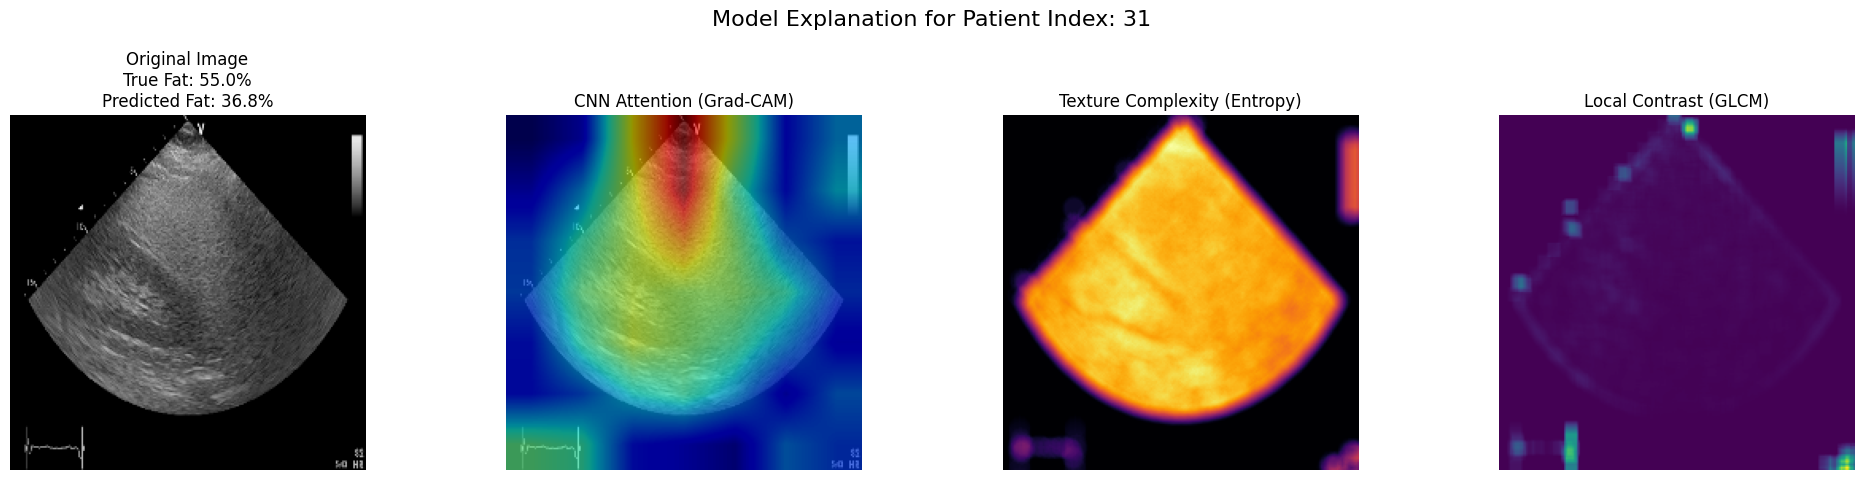

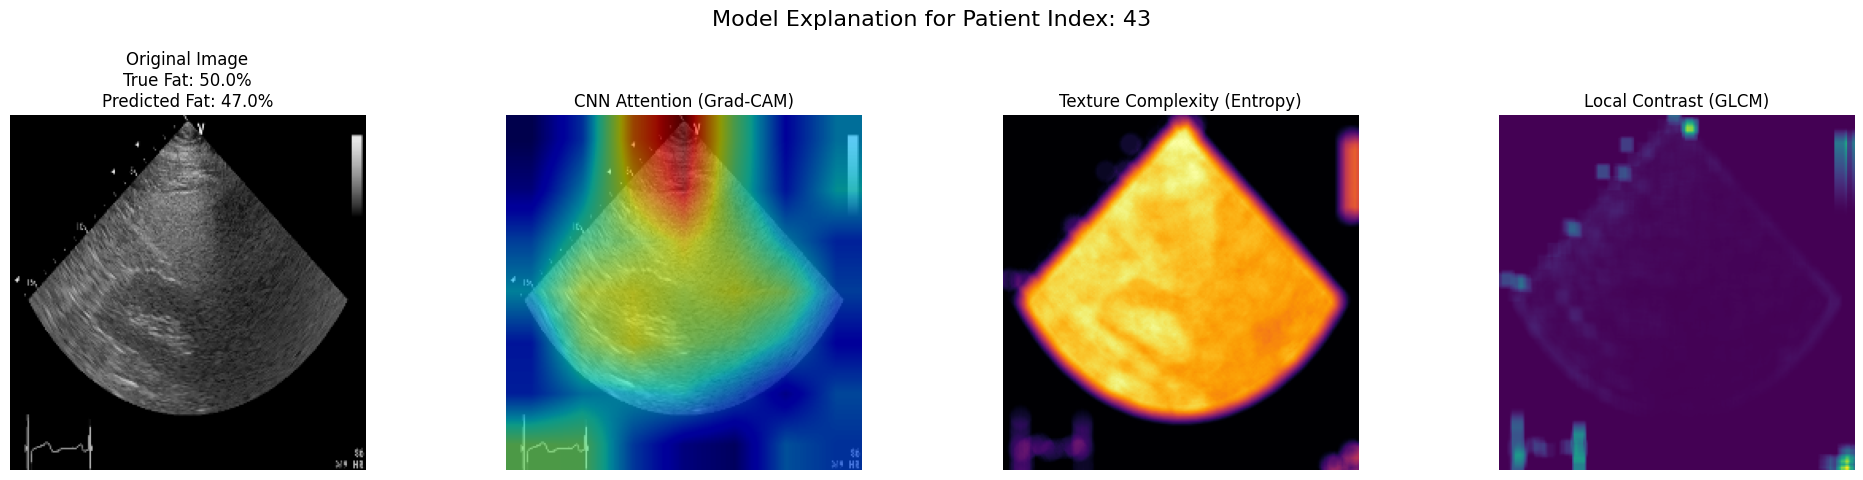

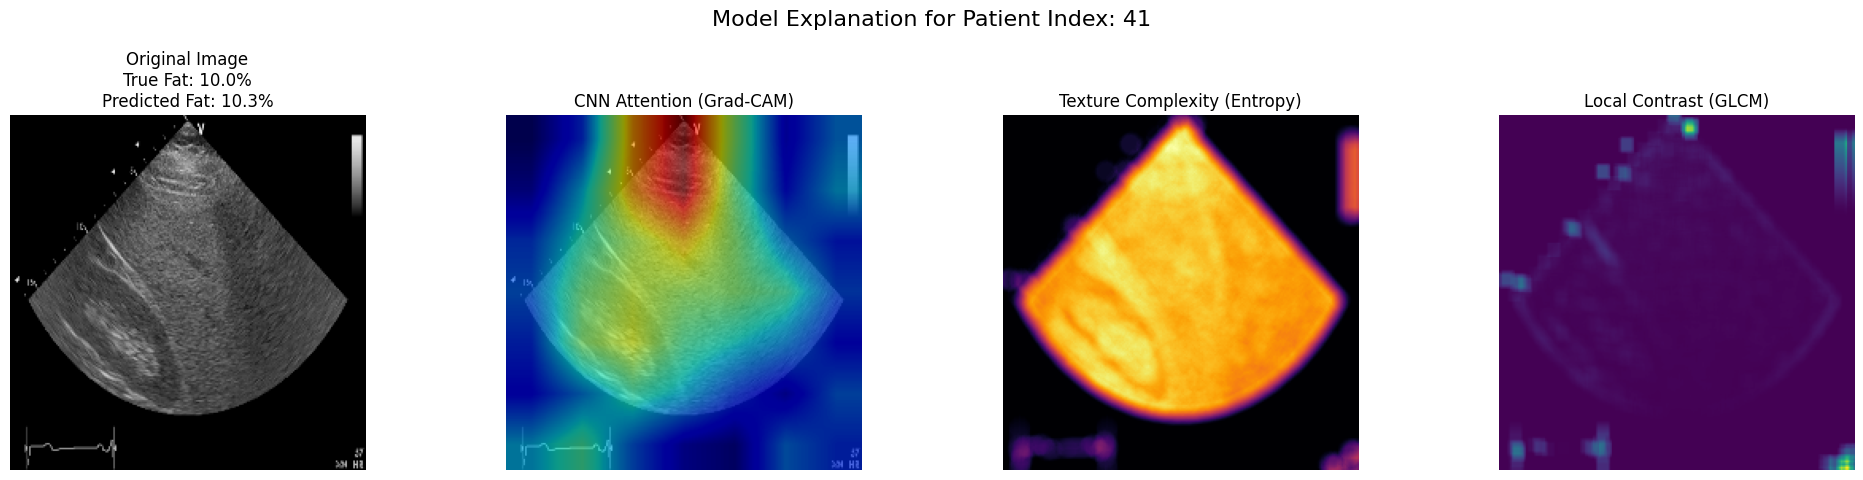

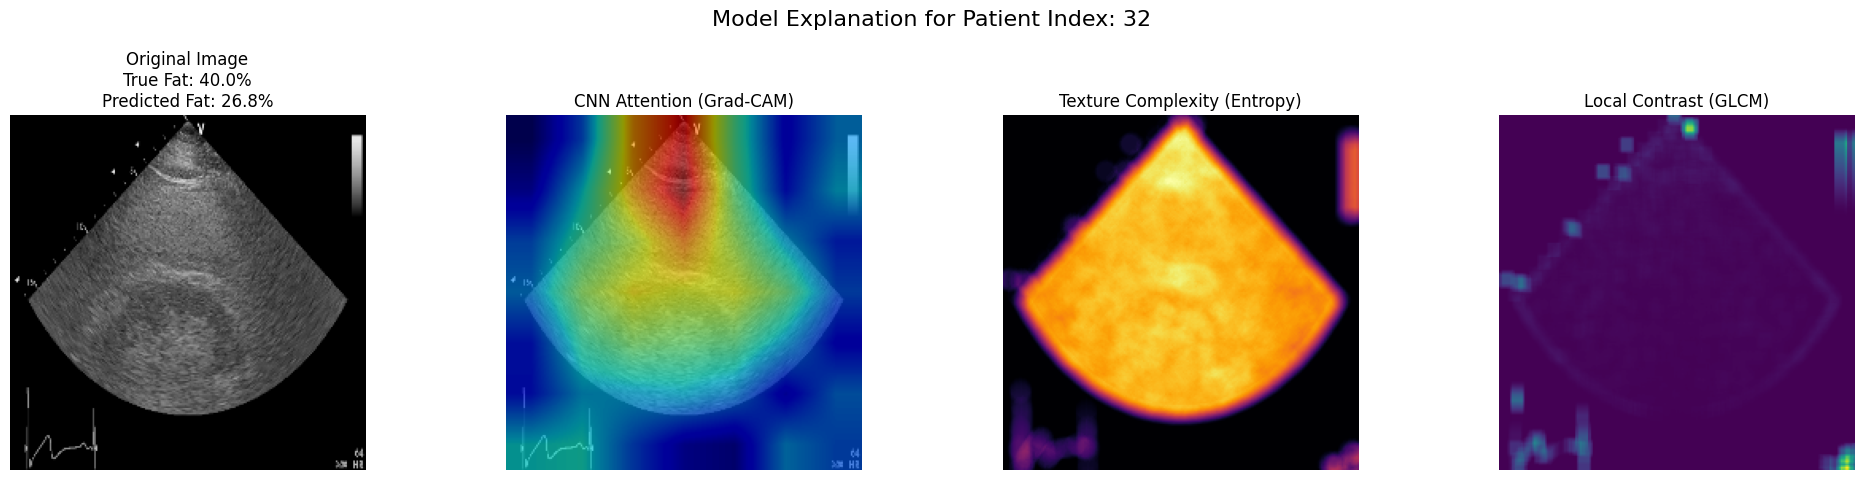

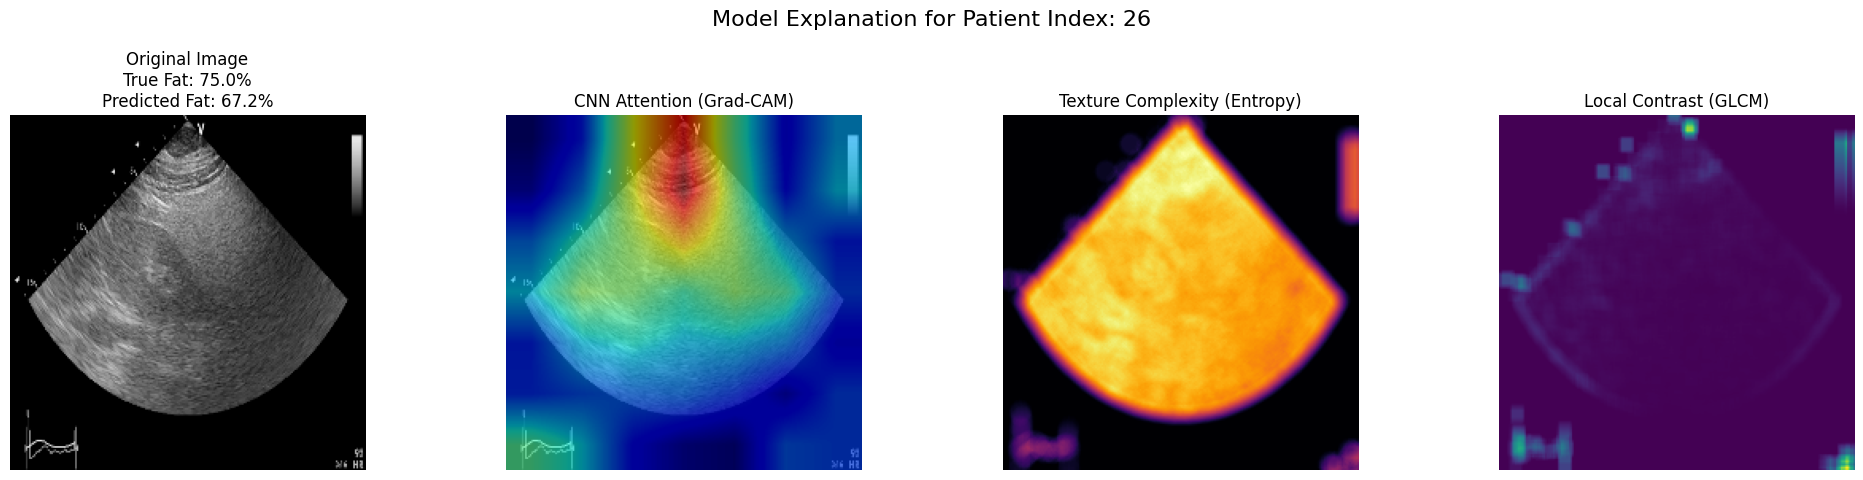

In [ ]:
# ===============================================
# Part 9: Visualizing Model Explanations (XAI)
# ===============================================
import random
import joblib
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import rank
from skimage.morphology import disk
from skimage.feature import graycomatrix, graycoprops

# Load the trained regressor model
model_filename = "xgb_efficientnet_image_wise_regressor.pkl"
regressor = joblib.load(model_filename)
print(f"Loaded model: {model_filename}")

def visualize_image_features(patient_idx, image_num, model, cnn_model_vis):
    """
    Generates and displays feature heatmaps for a single image to explain
    the regressor model's prediction.
    """
    # --- 1. Load Data & Make Prediction ---
    patient_data = data[patient_idx]
    image = patient_data.images[image_num,:,:]
    true_fat_percentage = patient_data.fat

    # Extract features for the single image
    cnn_feat = extract_cnn_features(image)
    texture_feat = extract_texture_features(image)
    feat_vector = np.concatenate([cnn_feat, texture_feat]).reshape(1, -1)

    # Get the predicted fat percentage directly from the regressor
    predicted_fat = model.predict(feat_vector)[0]

    # --- 2. Generate Feature Heatmaps ---
    resized_img = cv2.resize((image / image.max() * 255).astype(np.uint8), (224, 224))

    # a) CNN Grad-CAM (Attention Map for EfficientNet)
    # Target the main feature-producing block of EfficientNet
    feature_extractor_block = cnn_model_vis[0]
    feature_extractor_block.eval()
    img_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        feature_maps = feature_extractor_block(img_tensor)

    heatmap = feature_maps.mean(dim=1).squeeze().cpu().numpy()
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # b) Entropy Map (Textural Complexity)
    entropy_map = rank.entropy(resized_img, disk(7))

    # c) GLCM Contrast Map (Local Edge & Intensity Variation)
    glcm_map = np.zeros_like(resized_img, dtype=np.float32)
    window_size = 9
    padded_img = cv2.copyMakeBorder(resized_img, window_size//2, window_size//2, window_size//2, window_size//2, cv2.BORDER_REFLECT)
    for i in range(resized_img.shape[0]):
        for j in range(resized_img.shape[1]):
            patch = padded_img[i:i+window_size, j:j+window_size]
            if patch.max() > 0:
                glcm = graycomatrix(patch, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
                glcm_map[i, j] = graycoprops(glcm, 'contrast')[0, 0]
    glcm_map = cv2.normalize(glcm_map, None, 0, 255, cv2.NORM_MINMAX)

    # --- 3. Plot Everything ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(resized_img, cmap='gray')
    axes[0].set_title(f"Original Image\nTrue Fat: {true_fat_percentage:.1f}%\nPredicted Fat: {predicted_fat:.1f}%")
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].imshow(resized_img, cmap='gray', alpha=0.4)
    axes[1].set_title("CNN Attention (Grad-CAM)")
    axes[1].axis('off')

    axes[2].imshow(entropy_map, cmap='inferno')
    axes[2].set_title("Texture Complexity (Entropy)")
    axes[2].axis('off')

    axes[3].imshow(glcm_map, cmap='viridis')
    axes[3].set_title("Local Contrast (GLCM)")
    axes[3].axis('off')

    plt.suptitle(f"Model Explanation for Patient Index: {patient_idx}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Visualize predictions on 5 random patients from the TEST set ---
random_test_patient_indices = random.sample(list(test_patient_idx), 5)

print(f"\nVisualizing 5 random patients from the test set: {random_test_patient_indices}")
for idx in random_test_patient_indices:
    # We'll visualize the first image from each selected patient's stack
    visualize_image_features(patient_idx=idx, image_num=0, model=regressor, cnn_model_vis=cnn_model)

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import rank
from skimage.morphology import disk
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import scipy.io as io
from tqdm import tqdm
import joblib

# # ------------------------
# # 1. Download and Load Dataset
# # ------------------------
# # Download the .mat file from Zenodo
# !wget "https://zenodo.org/records/1009146/files/dataset_liver_bmodes_steatosis_assessment_IJCARS.mat?download=1" -O dataset.mat

# Load the .mat file
mat = io.loadmat('dataset.mat', squeeze_me=True, struct_as_record=False)
data = mat['data']

# Number of patients
num_patients = len(data)
patient_ids = [f'patient_{i+1}' for i in range(num_patients)]

# Extract labels: binary classification (0: non-fatty <=5%, 1: fatty >5%)
patient_labels = {}
for i in range(num_patients):
    fat_percentage = data[i].fat
    label = 1 if fat_percentage > 50 else 0
    patient_labels[patient_ids[i]] = label

# ------------------------
# 2. CNN Backbone (Feature Extraction)
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
cnn_model = nn.Sequential(*list(cnn_model.children())[:-1])  # Remove final classifier layer
cnn_model.to(device)
cnn_model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def extract_cnn_features(image):
    # image is grayscale numpy array (H, W)
    img_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = cnn_model(img_tensor)
    return features.cpu().numpy().flatten()

# ------------------------
# 3. Texture Features
# ------------------------
def extract_texture_features(image):
    # image is grayscale numpy array (H, W)
    gray = cv2.resize(image, (224, 224))

    # GLCM features
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    # Local entropy
    entropy = rank.entropy(gray, disk(5)).mean()

    return [contrast, energy, homogeneity, entropy]
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np

# Placeholder function for quantum-inspired features
import cv2
def extract_quantum_features_small(image, k=200):
    """
    Downsample image, compute quantum-inspired features, and take top-K.
    """
    # Resize to small resolution
    img_small = cv2.resize(image, (64, 64))  # or (32,32) for more speed
    img_norm = img_small / 255.0

    # Angle encoding
    theta = img_norm * np.pi
    angle_feat = np.concatenate([np.cos(theta).flatten(), np.sin(theta).flatten()])

    # Simplified Hopfield energy (sum of outer product diagonals)
    hopfield_feat = np.array([np.sum(np.diag(np.outer(img_norm.flatten(), img_norm.flatten())))])

    quantum_feat = np.concatenate([angle_feat, hopfield_feat])

    # Select top-K by absolute value
    topk_indices = np.argsort(np.abs(quantum_feat))[-k:]
    return quantum_feat[topk_indices]



# ------------------------
# 4. Aggregate Features per Patient
# ------------------------
X_all, X_quantum, X_entropy, X_glcm = [], [], [], []
y = []

for i, pid in enumerate(tqdm(patient_ids, desc="Processing patients")):
    patient_data = data[i]
    images = patient_data.images
    num_images = images.shape[0]

    feats_all, feats_quantum, feats_entropy, feats_glcm = [], [], [], []

    for j in range(num_images):
        img = images[j, :, :]
        if img.dtype != np.uint8:
            img = (img / img.max() * 255).astype(np.uint8)

        # Quantum features (downsample + top-K)
        quantum_feat = extract_quantum_features_small(img, k=200)


        # --- Classical features ---
        cnn_feat = extract_cnn_features(img)
        glcm_feat = extract_texture_features(img)[:3]  # contrast, energy, homogeneity
        entropy_feat = np.array([extract_texture_features(img)[-1]])  # only entropy
        # Quantum features (downsample + top-K)
        quantum_feat = extract_quantum_features_small(img, k=200)

        # --- Aggregate per image ---
        feats_all.append(np.concatenate([cnn_feat, glcm_feat, entropy_feat, quantum_feat]))
        feats_quantum.append(quantum_feat)
        feats_entropy.append(entropy_feat)
        feats_glcm.append(glcm_feat)

    # --- Aggregate per patient (mean over images) ---
    X_all.append(np.mean(feats_all, axis=0))
    X_quantum.append(np.mean(feats_quantum, axis=0))
    X_entropy.append(np.mean(feats_entropy, axis=0))
    X_glcm.append(np.mean(feats_glcm, axis=0))
    y.append(patient_labels[pid])

X_all, X_quantum, X_entropy, X_glcm, y = map(np.array, [X_all, X_quantum, X_entropy, X_glcm, y])


# ------------------------
# 5. Train Classifier (Optimized for Speed) with GridSearch for Best Model
# ------------------------
def train_and_save_model(X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {'n_estimators': [50, 100], 'max_depth': [10, None]}
    clf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
    grid = GridSearchCV(clf_base, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    clf = grid.best_estimator_

    y_pred = clf.predict(X_test)
    print(f"\n--- {model_name} ---")
    print(f"Best parameters: {grid.best_params_}")
    print(classification_report(y_test, y_pred))

    joblib.dump(clf, f"{model_name}.pkl")
    print(f"{model_name} saved successfully!\n")
    return clf

# --- Train all four models ---
clf_all = train_and_save_model(X_all, y, "model_all_features")
clf_quantum = train_and_save_model(X_quantum, y, "model_quantum_features")
clf_entropy = train_and_save_model(X_entropy, y, "model_entropy_features")
clf_glcm = train_and_save_model(X_glcm, y, "model_glcm_features")




Processing patients: 100%|██████████| 55/55 [02:49<00:00,  3.09s/it]



--- model_all_features ---
Best parameters: {'max_depth': 10, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.80      1.00      0.89         8

    accuracy                           0.82        11
   macro avg       0.90      0.67      0.69        11
weighted avg       0.85      0.82      0.78        11

model_all_features saved successfully!


--- model_quantum_features ---
Best parameters: {'max_depth': 10, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       0.80      0.50      0.62         8

    accuracy                           0.55        11
   macro avg       0.57      0.58      0.53        11
weighted avg       0.67      0.55      0.57        11

model_quantum_features saved successfully!


--- model_entropy_features ---
Best parameters: {'max_depth': 10, 'n_estimators': 50}
     